In [3]:
import seaborn as sns

print("Seaborn installed successfully!")

Seaborn installed successfully!


In [4]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_breast_cancer

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(data.target)

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (569, 30)
Target Shape: (569,)


## Observation 1

The Breast Cancer Wisconsin dataset contains 569 samples and 30 numerical features. The target variable contains a binary classification label indicating whether a tumor is malignant or benign. The dataset is suitable for a supervised classification task.

In [6]:
print(X.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [7]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [8]:
print(X.isnull().sum())

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64


## Observation 2

All 30 features contain zero missing values. Therefore, no imputation or row removal was required during data preprocessing.

In [9]:
print(data.target_names)
print(y.value_counts())

['malignant' 'benign']
1    357
0    212
Name: count, dtype: int64


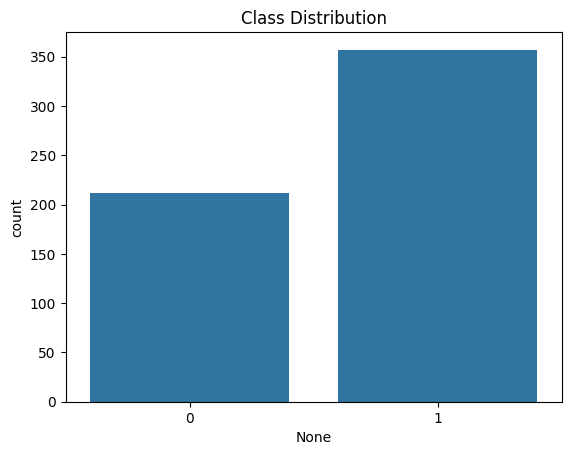

In [10]:
sns.countplot(x=y)

plt.title("Class Distribution")
plt.show()

## Observation 3

The class distribution plot shows that benign tumors are more frequent than malignant tumors. The dataset contains 357 benign cases and 212 malignant cases. The class imbalance is moderate and therefore no additional balancing techniques were applied.

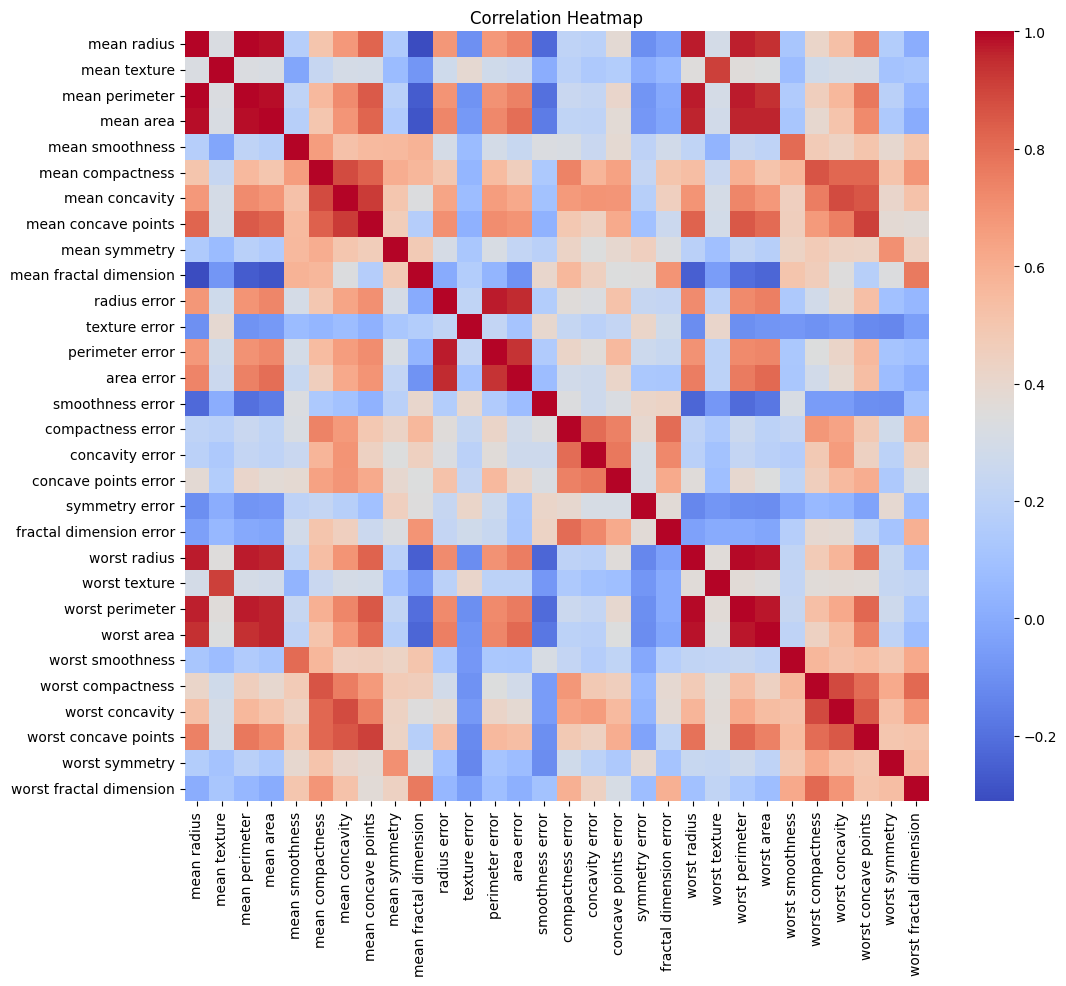

In [11]:
plt.figure(figsize=(12,10))

sns.heatmap(
    X.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [12]:
corr_matrix = X.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = [
    column
    for column in upper.columns
    if any(upper[column] > 0.95)
]

print(high_corr)

['mean perimeter', 'mean area', 'perimeter error', 'area error', 'worst radius', 'worst perimeter', 'worst area']


In [13]:
X_selected = X.drop(columns=high_corr)

print("Original shape:", X.shape)
print("New shape:", X_selected.shape)

Original shape: (569, 30)
New shape: (569, 23)


## Observation 4

A correlation heatmap was used to identify highly correlated features. Features with an absolute correlation greater than 0.95 were considered redundant and removed. Seven highly correlated features were dropped, reducing the number of features from 30 to 23. This helped reduce multicollinearity and simplify the model while retaining most of the predictive information.

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (455, 23)
X_test: (114, 23)
y_train: (455,)
y_test: (114,)


## Observation 5

The dataset was split into training and testing sets using an 80:20 ratio. Stratified sampling was applied to preserve the original class distribution in both sets. The training set contains 455 samples, while the testing set contains 114 samples.

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(455, 23)
(114, 23)


In [16]:
print("Before Scaling:")
print(X_train.head())

print("\nAfter Scaling:")
print(X_train_scaled[:5])

Before Scaling:
     mean radius  mean texture  mean smoothness  mean compactness  \
546        10.32         16.35          0.09434           0.04994   
432        20.18         19.54          0.11330           0.14890   
174        10.66         15.15          0.08792           0.04302   
221        13.56         13.90          0.10510           0.11920   
289        11.37         18.89          0.08713           0.05008   

     mean concavity  mean concave points  mean symmetry  \
546         0.01012             0.005495         0.1885   
432         0.21330             0.125900         0.1724   
174         0.00000             0.000000         0.1928   
221         0.07860             0.044510         0.1962   
289         0.02399             0.021730         0.2013   

     mean fractal dimension  radius error  texture error  ...  \
546                 0.06201        0.2104         0.9670  ...   
432                 0.06053        0.4331         1.0010  ...   
174                

In [17]:
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_train_scaled_df.head()

,mean radius,mean texture,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,...,concave points error,symmetry error,fractal dimension error,worst texture,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,-1.072001,-0.658425,-0.135940,-1.008718,-0.968359,-1.102032,0.281062,-0.113231,-0.704861,-0.440938,...,-0.983284,-0.591579,-0.428972,-0.623497,-0.169982,-1.038836,-1.078995,-1.350527,-0.352658,-0.541380
1,1.748743,0.066502,1.274468,0.842288,1.519852,1.994664,-0.293045,-0.320180,0.127567,-0.381383,...,1.182150,0.426212,0.074797,-0.092833,1.517001,0.249655,1.178594,1.549916,0.191078,-0.173739
2,-0.974734,-0.931124,-0.613515,-1.138154,-1.092292,-1.243358,0.434395,-0.429247,-0.254445,1.237130,...,-1.857894,1.356046,-1.006560,-1.036772,-1.097823,-1.167260,-1.282241,-1.707442,-0.307734,-1.213033
3,-0.145103,-1.215186,0.664482,0.286762,-0.129729,-0.098605,0.555635,0.029395,-0.531049,-1.262281,...,-0.527278,-0.269450,-0.316623,-1.369643,0.234006,0.096874,-0.087521,-0.344838,0.242198,-0.118266
4,-0.771617,-0.081211,-0.672282,-1.006099,-0.798502,-0.684484,0.737495,-0.457213,-0.498529,1.322961,...,-0.278344,1.528534,-0.313022,0.079230,-0.911367,-0.984612,-0.933190,-0.777604,0.555118,-0.761639


## Observation 6

The numerical features were standardized using StandardScaler. The scaler was fitted on the training set and then applied to both training and testing data to prevent data leakage. Standardization ensures that all features have a comparable scale, improving model training and convergence.

In [18]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=5000)

lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


## Observation 7

A Logistic Regression classifier was trained on the standardized training dataset. The model converged successfully without warnings and will serve as the baseline classifier for performance comparison.

In [19]:
y_pred_lr = lr.predict(X_test_scaled)

print(y_pred_lr[:10])

[0 1 0 1 0 1 1 0 0 0]


In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

Accuracy : 0.9736842105263158
Precision: 0.9859154929577465
Recall   : 0.9722222222222222
F1 Score : 0.9790209790209791


## Observation 8

The Logistic Regression model achieved an accuracy of 97.37%, precision of 98.59%, recall of 97.22%, and an F1-score of 97.90%. The results indicate that the model performs exceptionally well on the Breast Cancer dataset and serves as a strong baseline classifier.

In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.95      0.98      0.96        42
           1       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



## Observation 9

The classification report shows strong performance for both malignant and benign tumor classes. The model achieved a recall of 98% for malignant tumors, which is particularly important in a medical diagnosis setting because it minimizes the risk of missing cancer cases. Macro and weighted averages are both approximately 97%, indicating balanced performance across classes.

In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

print(cm)

[[41  1]
 [ 2 70]]


## Observation 10

The confusion matrix shows that the Logistic Regression model correctly classified 111 out of 114 test samples. Only three misclassifications occurred. Most importantly, only one malignant tumor was incorrectly classified as benign, indicating strong diagnostic reliability for medical screening applications.

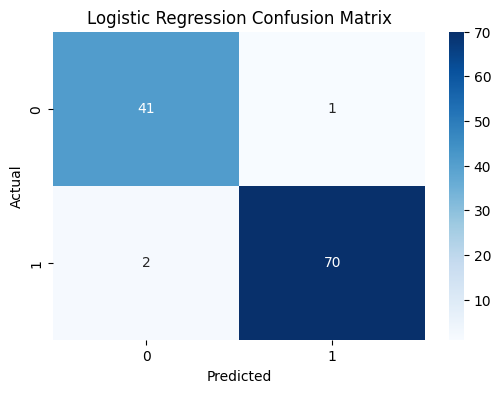

In [23]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

## Observation 11

The confusion matrix visually confirms the strong performance of the Logistic Regression model. Out of 114 test samples, 111 were classified correctly. Only three misclassifications occurred, with a single malignant tumor being incorrectly classified as benign. This indicates a low false-negative rate and makes the model suitable for medical diagnosis support.

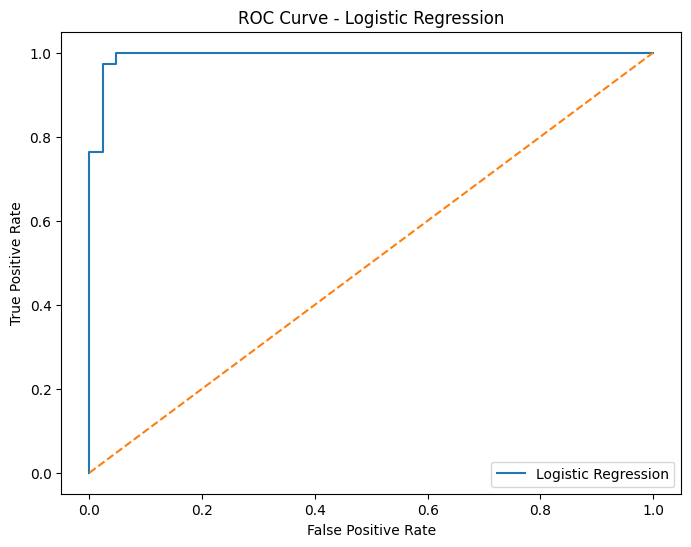

In [24]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label="Logistic Regression")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()

In [25]:
auc_lr = roc_auc_score(y_test, y_prob_lr)

print("AUC Score:", auc_lr)

AUC Score: 0.9937169312169312


## Observation 12

The Logistic Regression model achieved an AUC score of 0.9937, indicating excellent discriminative ability between malignant and benign tumors. The ROC curve lies close to the upper-left corner of the graph, demonstrating a high true positive rate and a low false positive rate across different classification thresholds.

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Observation 13

A Random Forest classifier containing 100 decision trees was trained on the selected features. Random Forest does not require feature scaling because decisions are based on feature thresholds rather than distances.

In [27]:
y_pred_rf = rf.predict(X_test)

print(y_pred_rf[:10])

[0 1 0 1 0 1 1 0 0 0]


In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Accuracy : 0.9649122807017544
Precision: 0.9594594594594594
Recall   : 0.9861111111111112
F1 Score : 0.9726027397260274


## Observation 14

The Random Forest classifier achieved an accuracy of 96.49%, precision of 95.95%, recall of 98.61%, and an F1-score of 97.26%. While Random Forest achieved slightly higher recall, Logistic Regression performed better overall in terms of accuracy, precision, and F1-score.

In [29]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.97      0.93      0.95        42
           1       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



## Observation 15

The Random Forest classification report shows strong performance for both classes. However, Logistic Regression achieved a higher recall for malignant tumors (98% vs 93%), which is particularly important in medical diagnosis because it reduces the likelihood of missing cancer cases.

In [30]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[39  3]
 [ 1 71]]


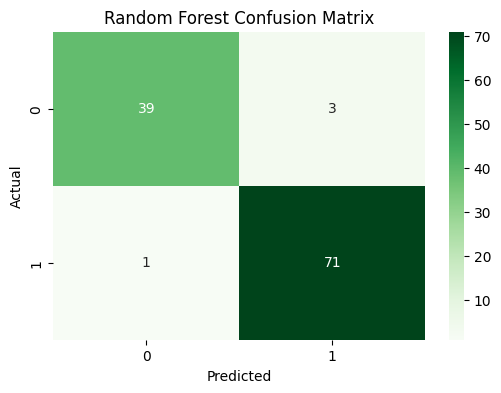

In [46]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

## Observation 16

The Random Forest confusion matrix shows four misclassifications out of 114 test samples. Although the model correctly identified more benign tumors, it misclassified three malignant tumors as benign. Since false negatives are particularly critical in medical diagnosis, Logistic Regression remains the preferred model at this stage.

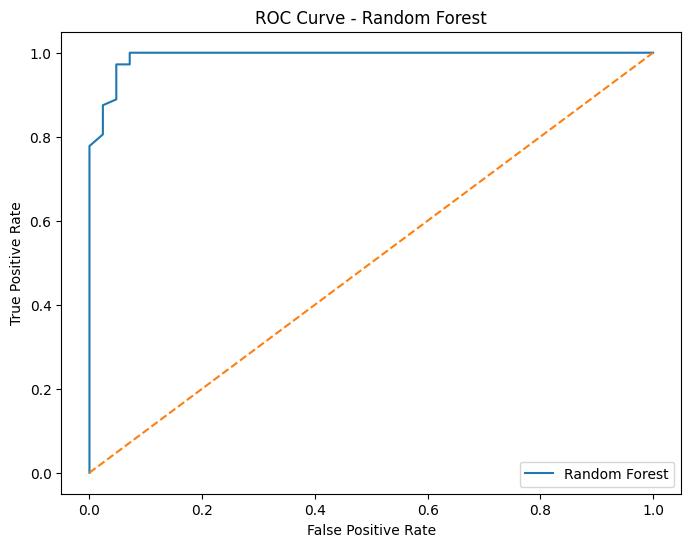

In [31]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob_rf = rf.predict_proba(X_test)[:, 1]

fpr_rf, tpr_rf, thresholds_rf = roc_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_rf,
    tpr_rf,
    label="Random Forest"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")

plt.legend()

plt.show()

In [32]:
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("AUC Score:", auc_rf)

AUC Score: 0.9915674603174602


## Observation 17

The Random Forest model achieved an AUC score of 0.9916, indicating excellent class separability. However, Logistic Regression achieved a slightly higher AUC score of 0.9937 and outperformed Random Forest on accuracy, precision, F1-score, and malignant tumor recall. Therefore, Logistic Regression is currently the preferred model for this dataset.

In [33]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

                 Feature  Importance
20  worst concave points    0.189261
5    mean concave points    0.177335
0            mean radius    0.113332
4         mean concavity    0.111946
19       worst concavity    0.078874
8           radius error    0.048417
16         worst texture    0.032197
3       mean compactness    0.031772
18     worst compactness    0.031077
1           mean texture    0.028279


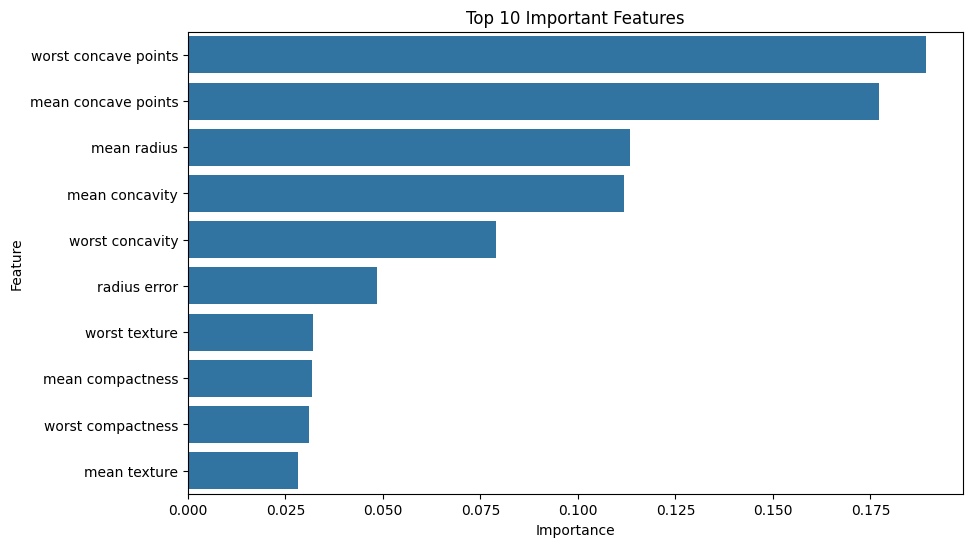

In [34]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title("Top 10 Important Features")
plt.show()

## Observation 18

Feature importance analysis revealed that worst concave points, mean concave points, mean radius, mean concavity, and worst concavity were the most influential features. These features describe tumor size and boundary irregularity, which are medically relevant indicators of breast cancer. The results therefore align with domain knowledge and support the model's interpretability.

In [37]:
from sklearn.model_selection import cross_val_score

lr_cv_scores = cross_val_score(
    lr,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("Logistic Regression CV Scores:")
print(lr_cv_scores)

print("Mean CV Accuracy:", lr_cv_scores.mean())

Logistic Regression CV Scores:
[0.95604396 0.97802198 0.96703297 0.98901099 0.97802198]
Mean CV Accuracy: 0.9736263736263735


In [38]:
rf_cv_scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("Random Forest CV Scores:")
print(rf_cv_scores)

print("Mean CV Accuracy:", rf_cv_scores.mean())

Random Forest CV Scores:
[0.93406593 1.         0.91208791 0.96703297 0.96703297]
Mean CV Accuracy: 0.956043956043956


## Observation 19

Five-fold cross-validation was performed to evaluate model stability and generalization. Logistic Regression achieved a mean cross-validation accuracy of 97.36%, while Random Forest achieved 95.60%. Logistic Regression also exhibited more consistent performance across folds, suggesting better generalization on this dataset.

In [39]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}

Best CV Accuracy:
0.956043956043956


## Observation 20

Hyperparameter tuning was performed using GridSearchCV. The optimal parameters were found to be max_depth=None, min_samples_split=2, and n_estimators=100. The tuned model achieved the same cross-validation accuracy as the original model (95.60%), indicating that the initial Random Forest configuration was already close to optimal.

In [40]:
import time

start = time.time()

lr.fit(X_train_scaled, y_train)

lr_time = time.time() - start

print("Logistic Regression Training Time:", lr_time)

Logistic Regression Training Time: 0.016234874725341797


In [41]:
start = time.time()

rf.fit(X_train, y_train)

rf_time = time.time() - start

print("Random Forest Training Time:", rf_time)

Random Forest Training Time: 0.2227942943572998


## Observation 21

Training time was compared for both models. Logistic Regression completed training in approximately 0.016 seconds, while Random Forest required approximately 0.223 seconds. Logistic Regression was significantly faster while also achieving better predictive performance.

In [44]:
comparison = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'AUC',
        'CV Accuracy',
        'Training Time (s)'
    ],
    'Logistic Regression': [
        0.9737,
        0.9859,
        0.9722,
        0.9790,
        0.9937,
        0.9736,
        0.0162
    ],
    'Random Forest': [
        0.9649,
        0.9595,
        0.9861,
        0.9726,
        0.9916,
        0.9560,
        0.2228
    ]
})

comparison

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.9737,0.9649
1,Precision,0.9859,0.9595
2,Recall,0.9722,0.9861
3,F1 Score,0.9790,0.9726
4,AUC,0.9937,0.9916
5,CV Accuracy,0.9736,0.9560
6,Training Time (s),0.0162,0.2228


## Observation 22

Both Logistic Regression and Random Forest achieved excellent classification performance. However, Logistic Regression outperformed Random Forest in terms of accuracy, precision, F1-score, AUC score, cross-validation accuracy, and training time. Although Random Forest achieved slightly higher recall for benign tumors, Logistic Regression demonstrated superior overall performance and better generalization.

In [43]:
import joblib

joblib.dump(lr, "best_model.pkl")

print("Model saved successfully!")

Model saved successfully!


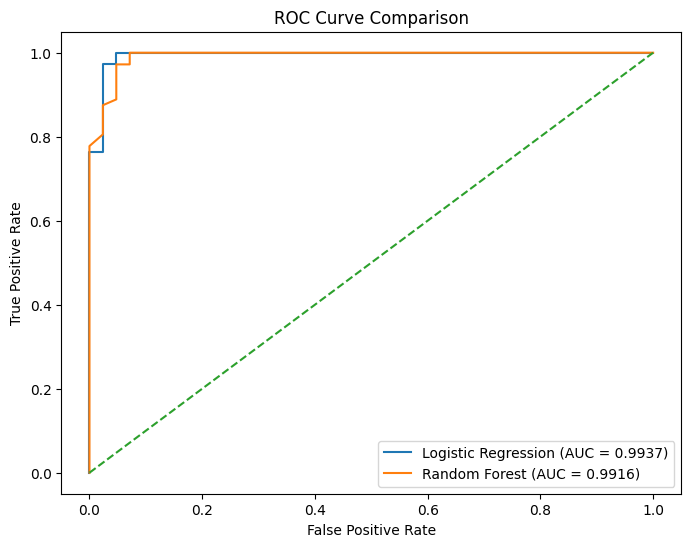

In [45]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f'Logistic Regression (AUC = {auc_lr:.4f})'
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest (AUC = {auc_rf:.4f})'
)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')

plt.legend()

plt.show()

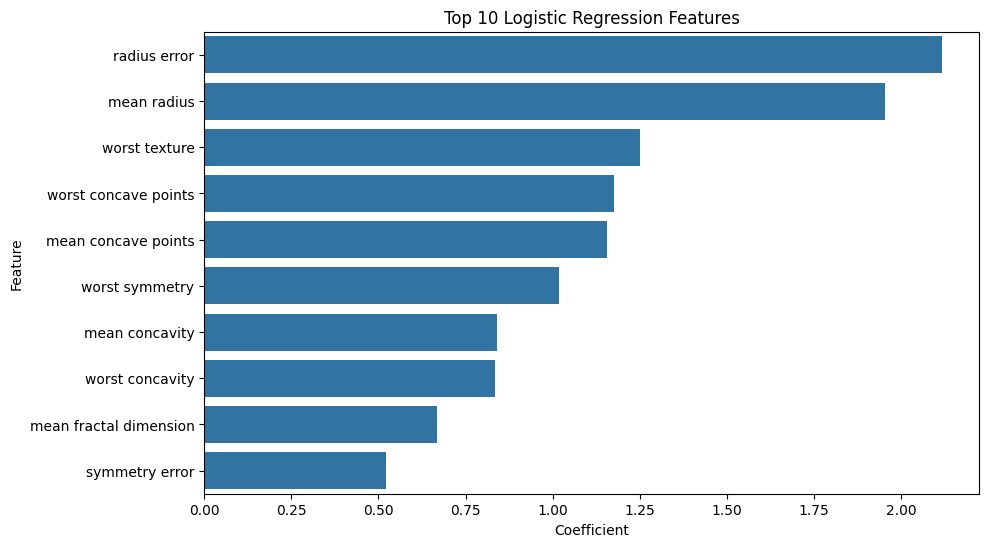

In [48]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': abs(lr.coef_[0])
})

coef_df = coef_df.sort_values(
    by='Coefficient',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Coefficient',
    y='Feature',
    data=coef_df.head(10)
)

plt.title('Top 10 Logistic Regression Features')

plt.show()